# SysQ Quantitative Trading System Tutorial

Welcome to the **SysQ** interactive tutorial. This notebook will guide you through the entire workflow of a professional quantitative trading system, from data acquisition to real-time trading signals.

### Workflow Overview:
1.  **Data Engineering**: Fetch historical data (All A-Shares) and perform **incremental updates** to the high-performance Qlib binary format.
2.  **Feature Engineering**: Generate Alpha158 factors using Qlib's expression engine.
3.  **Model Training**: Train a LightGBM model to predict **5-day future returns** (Weekly Alpha).
4.  **Backtesting**: Simulate trading with a rigorous event-driven engine.
5.  **Live Trading**: Generate a trading plan for the next market day and push alerts via Enterprise WeChat.

---

## 1. Environment Setup

Initialize the system configuration and logging.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to path
project_root = Path("../").resolve()
sys.path.append(str(project_root))

from qsys.config import cfg
from qsys.utils.logger import log
from qsys.data.adapter import QlibAdapter
from qsys.data.collector import TushareCollector

print(f"Project Root: {project_root}")
print("Environment initialized.")

Project Root: /Users/liuming/Documents/trae_projects/SysQ
Environment initialized.


## 2. Data Engineering

### 2.1 Fetching Data (CSI 300)

In a production environment, we need fresh data. We use `TushareCollector` to fetch the latest history for the CSI 300 universe. 

> **Pro Tip**: This step requires a Tushare API Token. Ensure `TUSHARE_TOKEN` is set in your environment or `config.yaml`.

*(Note: For this tutorial, if you already have local data, you can skip the fetching step by setting `FETCH_NEW_DATA = False`)*

In [2]:
FETCH_NEW_DATA = False  # Set to True to actually fetch from Tushare

if FETCH_NEW_DATA:
    print("Fetching latest CSI 300 data from Tushare...")
    collector = TushareCollector()
    # Fetch history from 2010 to present
    collector.update_universe_history(universe='all', start_date='20100101')
else:
    print("Skipping data fetch (using existing local raw data).")

Skipping data fetch (using existing local raw data).


### 2.2 Incremental Update to Qlib

Converting raw CSV/Feather data to Qlib's binary format is expensive. 
SysQ uses an **Incremental Update** mechanism. It checks the last date in the Qlib bin and only appends new data.

We set `force=False` to enable this smart update.

In [3]:
adapter = QlibAdapter()

# force=False enables incremental update (fast)
# force=True would trigger a full rebuild (slow)
print("Checking and synchronizing Qlib data...")
adapter.check_and_update(force=False)

# Initialize Qlib Runtime
adapter.init_qlib()

2026-02-08 18:40:01 | INFO     | qsys.data.adapter:check_and_update:66 - Raw data updated. Checking for new data since 2026-02-06...
2026-02-08 18:40:01 | INFO     | qsys.data.adapter:convert_incremental:174 - Starting incremental update (since 2026-02-06 00:00:00)...


Checking and synchronizing Qlib data...


2026-02-08 18:40:07 | INFO     | qsys.data.adapter:convert_incremental:178 - No new data found to update.
[94363:MainThread](2026-02-08 18:40:07,623) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[94363:MainThread](2026-02-08 18:40:07,884) INFO - qlib.Initialization - [__init__.py:82] - qlib successfully initialized based on client settings.
[94363:MainThread](2026-02-08 18:40:07,884) INFO - qlib.Initialization - [__init__.py:84] - data_path={'__DEFAULT_FREQ': PosixPath('/Users/liuming/Documents/trae_projects/SysQ/data/qlib_bin')}


### 2.3 Verify Data

Let's load a sample stock (e.g., Kweichow Moutai) to verify the data integrity.
**Crucial Step**: We must ensure `adj_factor` (Forward Adjustment Factor) is working to see the real price trend.

> **Note**: Tushare data uses `600519.SH` format. Do not use `SH600519`.

In [4]:
from qlib.data import D
from qsys.data.adapter import QlibAdapter
from qsys.utils.plotting import plot_forward_adjusted_candlestick, plot_price_verification

adapter = QlibAdapter()

instruments = D.instruments('all')
sample_stock = D.list_instruments(instruments=instruments, start_time='2023-01-01', end_time='2023-01-10')
if not sample_stock:
    print("Warning: No instruments found in Qlib!")
    stock_code = '600519.SH'
else:
    stock_code = '600519.SH' if '600519.SH' in sample_stock else list(sample_stock.keys())[0]

print(f"Verifying data for: {stock_code}")

df_sample = adapter.get_features(
    instruments=[stock_code],
    fields=['$open', '$high', '$low', '$close', '$factor', '$volume'],
    start_time='2022-01-01'
)

if df_sample.empty:
    print("Error: No data found for this stock.")
else:
    plot_forward_adjusted_candlestick(df_sample, stock_code)
    plot_price_verification(df_sample, stock_code)
    latest_factor = df_sample['$factor'].iloc[-1]
    if latest_factor == 0:
        latest_factor = 1.0
    adj_close = df_sample['$close'] * (df_sample['$factor'] / latest_factor)
    print("Last raw close:", df_sample['$close'].iloc[-1])
    print("Last adj close:", adj_close.iloc[-1])
    print(f"Data Rows: {len(df_sample)}")
    print(df_sample.head())

Verifying data for: 600519.SH


Last raw close: 1515.01
Last adj close: 1515.01
Data Rows: 994
                            $open        $high         $low       $close  \
instrument datetime                                                        
600519.SH  2022-01-04  2055.00000  2068.949951  2014.000000  2051.229980   
           2022-01-05  2045.00000  2065.000000  2018.000000  2024.000000   
           2022-01-06  2022.01001  2036.000000  1938.510010  1982.219971   
           2022-01-07  1975.00000  1988.880005  1939.319946  1942.000000   
           2022-01-10  1928.01001  1977.000000  1917.550049  1966.000000   

                       $factor    $volume  
instrument datetime                        
600519.SH  2022-01-04    7.474  3384262.0  
           2022-01-05    7.474  2839551.0  
           2022-01-06    7.474  5179475.0  
           2022-01-07    7.474  2981669.0  
           2022-01-10    7.474  2962670.0  


## 3. Feature Research (Rank IC)

We evaluate candidate features by **Rank IC** to filter the most stable signals before training.

> **Tip**: Rank IC is more robust than raw IC for cross-sectional alpha screening.

In [5]:
from qsys.feature.library import FeatureResearch, FeatureLibrary
from qsys.data.adapter import QlibAdapter

raw_config = FeatureLibrary.get_alpha158_config()
label = ["(Ref($close, -5) / Ref($close, -1) - 1)"]
feature_fields = raw_config
instruments = QlibAdapter().normalize_instruments("all")

report = FeatureResearch.rank_features_by_ic(
    instruments=instruments,
    start_time="2015-01-01",
    end_time="2021-12-31",
    label=label,
    feature_fields=feature_fields,
    topk=None,
    normalize=True
)

if report is None or report.empty or "ic_mean" not in report.columns or "icir" not in report.columns:
    raise ValueError("Feature selection failed. Check data coverage or label/feature config.")

report["abs_ic"] = report["ic_mean"].abs()
report["abs_icir"] = report["icir"].abs()
filtered = report[(report["abs_ic"] > 0.02) & (report["abs_icir"] > 0.3)]
selected = filtered if not filtered.empty else report
top_features = selected.sort_values("abs_icir", ascending=False).head(100)["feature"].tolist()

print("Top features by Rank IC IR:")
display(selected.head(10))

2026-02-08 18:40:08 | INFO     | qsys.data.adapter:check_and_update:69 - Qlib bin is up to date.
[94363:MainThread](2026-02-08 18:40:08,900) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[94363:MainThread](2026-02-08 18:40:08,903) INFO - qlib.Initialization - [__init__.py:82] - qlib successfully initialized based on client settings.
[94363:MainThread](2026-02-08 18:40:08,904) INFO - qlib.Initialization - [__init__.py:84] - data_path={'__DEFAULT_FREQ': PosixPath('/Users/liuming/Documents/trae_projects/SysQ/data/qlib_bin')}
[94363:MainThread](2026-02-08 18:41:42,008) INFO - qlib.timer - [log.py:127] - Time cost: 93.102s | Loading data Done
/Users/liuming/miniforge3/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning:

All-NaN slice encountered

[94363:MainThread](2026-02-08 18:41:44,128) INFO - qlib.timer - [log.py:127] - Time cost: 2.003s | RobustZScoreNorm Done
[94363:MainThread](2026-02-08 18:41:44,314) INFO - qlib.timer - [log.py:1

Top features by Rank IC IR:


,feature,ic_mean,ic_std,icir,ric_mean,ric_std,ricir,sample_count,abs_ic,abs_icir
17,"Mean($close, 5)/$close",0.009377,0.174181,0.053838,0.033173,0.183512,0.180766,401904,0.009377,0.053838
52,"Quantile($close, 5, 0.8)/$close",0.014349,0.166690,0.086081,0.030811,0.178255,0.172849,401904,0.014349,0.086081
57,"Quantile($close, 5, 0.2)/$close",0.007919,0.168677,0.046950,0.030338,0.177361,0.171055,401904,0.007919,0.046950
15,"Ref($close, 30)/$close",0.023528,0.195842,0.120138,0.032784,0.205619,0.159441,394082,0.023528,0.120138
12,"Ref($close, 5)/$close",0.011684,0.178036,0.065626,0.029721,0.188238,0.157890,399503,0.011684,0.065626
58,"Quantile($close, 10, 0.2)/$close",0.003397,0.171806,0.019770,0.028013,0.182496,0.153499,401904,0.003397,0.019770
18,"Mean($close, 10)/$close",0.004590,0.176071,0.026067,0.028071,0.188498,0.148920,401904,0.004590,0.026067
53,"Quantile($close, 10, 0.8)/$close",0.009761,0.168560,0.057907,0.026720,0.186252,0.143463,401904,0.009761,0.057907
21,"Mean($close, 60)/$close",0.008640,0.194081,0.044518,0.029268,0.207087,0.141331,401904,0.008640,0.044518
60,"Quantile($close, 30, 0.2)/$close",-0.000380,0.184949,-0.002053,0.027097,0.193812,0.139813,401904,0.000380,0.002053


## 4. Model Training (Weekly Alpha)

We will train a LightGBM model. 

### Key Changes:
1.  **Label**: Use **5-Day Return** and apply cross-sectional z-score normalization.
2.  **Features**: Use full Alpha158, normalize cross-sectionally, then select Top 100 by Rank IC.

> **Concept**: **Label Engineering** is critical. A 5-day horizon (weekly) is often more predictable for swing trading strategies than a 1-day horizon.

In [ ]:
# === Deep Debug: Data Inspection ===
import lightgbm as lgb
import numpy as np

# 1. Inspect Feature Matrix
print("1. Feature Matrix Stats:")
print(f"   Shape: {df_train_features.shape}")
print(f"   NaN Count: {df_train_features.isna().sum().sum()}")
# Check for all-zeros or constants
stds = df_train_features.std()
zero_std_cols = stds[stds == 0].index.tolist()
if len(zero_std_cols) > 0:
    print(f"   ⚠️ WARNING: {len(zero_std_cols)} features have 0 std (constant values).")
else:
    print("   ✅ OK: No constant features found.")

# 2. Check Correlation with Label
print("\n2. Feature-Label Correlation (Top 5):")
corrs = []
# Calculate correlation for a subset to save time
subset_corr = 10000
X_corr = df_train_features.iloc[-subset_corr:]
y_corr = df_train_label.iloc[-subset_corr:]
for col in X_corr.columns[:50]: # Check first 50 features
    c = X_corr[col].corr(y_corr.iloc[:,0])
    corrs.append((col, c))
corrs.sort(key=lambda x: abs(x[1]), reverse=True)
for name, c in corrs[:5]:
    print(f"   {name}: {c:.4f}")

# 3. Try to Overfit a small subset
print("\n3. Overfit Test (Small Subset)...")
subset_size = 1000
# CRITICAL FIX: Convert to numpy to strip column names and avoid JSON error
X_sub_val = df_train_features.iloc[:subset_size].values
y_sub = df_train_label.iloc[:subset_size]

# Check if Normalization happened
label_std = df_train_label.values.std()
if label_std < 0.2:
     print(f"   ⚠️ WARNING: Label STD is very low ({label_std:.4f}). CSZScoreNorm might NOT be working or raw returns are used.")
else:
     print(f"   ✅ OK: Label STD is {label_std:.4f}, looks normalized.")

# Create simple feature names f0, f1, ...
feat_names = [f"f{i}" for i in range(X_sub_val.shape[1])]
y_sub_norm = y_sub # Label is already normalized if CSZScoreNorm is working

lgb_train = lgb.Dataset(X_sub_val, label=y_sub_norm, feature_name=feat_names)

params_overfit = {
    'objective': 'mse',
    'metric': 'mse',
    'boosting_type': 'gbdt',
    'num_leaves': 128,  # Large enough
    'learning_rate': 0.1,
    'feature_fraction': 1.0,
    'bagging_fraction': 1.0,
    'verbosity': -1,
    'min_data_in_leaf': 1 # Allow splitting even with few data
}

print("   Training on subset...")
gbm_overfit = lgb.train(
    params_overfit,
    lgb_train,
    num_boost_round=100
)

pred_sub = gbm_overfit.predict(X_sub_val)
mse_sub = ((pred_sub - y_sub.values.flatten()) ** 2).mean()
print(f"   Subset MSE: {mse_sub:.6f}")

if mse_sub < 0.1: # Threshold for "fitting well" on normalized data (var ~ 1.0)
     print("   ✅ OK: Model CAN overfit small subset. Data contains signal (or at least distinctive patterns).")
else:
     print("   ❌ FAIL: Model CANNOT overfit. Feature matrix might be broken (all same values, NaNs, etc).")
     print("   Inspection needed: Check df_train_features.describe()")


In [7]:
from qlib.data import D
# 初始化后...

# 查一下最基础的字段
df_raw = D.features(
    instruments=['600519.SH'], # 随便找个存在的票
    fields=['$close', '$volume', '$amount', '$factor'],
    start_time='2020-01-01',
    end_time='2020-01-10'
)
print(df_raw)

                            $close     $volume       $amount  $factor
instrument datetime                                                  
600519.SH  2020-01-02  1130.000000  14809916.0  1.669684e+10   7.3186
           2020-01-03  1078.560059  13031878.0  1.426638e+10   7.3186
           2020-01-06  1077.989990   6341478.0  6.853918e+09   7.3186
           2020-01-07  1094.530029   4785359.0  5.220697e+09   7.3186
           2020-01-08  1088.140015   2500825.0  2.720372e+09   7.3186
           2020-01-09  1102.699951   3740587.0  4.110950e+09   7.3186
           2020-01-10  1112.500000   3597587.0  3.993457e+09   7.3186


## 5. Evaluation (Rank IC)

We evaluate the model's predictive power using **Information Coefficient (IC)** and **Rank IC**.
*   **IC**: Correlation between prediction and actual return.
*   **Rank IC**: Correlation of the *ranks* (more robust to outliers).
*   **ICIR**: IC divided by its standard deviation (stability of the alpha).

Mean IC: 0.0043
Mean Rank IC: -0.0154
ICIR: 0.0305


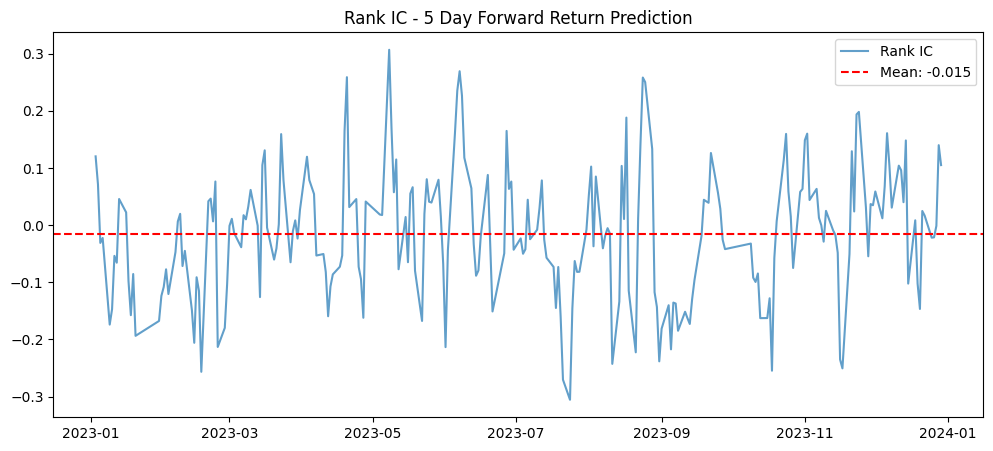

In [8]:
from qlib.contrib.eva.alpha import calc_ic

# Get label data
# prepare() returns DataFrame. To get label, we request col_set='label'
df_test = dh.prepare("test")
df_label = dh.prepare("test", col_set="label")

# Align indices
# 将 pred_test 转为 Series 后再构建 DataFrame，避免 index 参数与构造函数不匹配
pred_test_df = pd.DataFrame({'score': pd.Series(pred_test, index=df_test.index)})
df_combined = pd.concat([df_label, pred_test_df], axis=1)
df_combined.columns = ['label', 'score']

# Calculate IC
ic, ric = calc_ic(df_combined['score'], df_combined['label'])

print(f"Mean IC: {ic.mean():.4f}")
print(f"Mean Rank IC: {ric.mean():.4f}")
print(f"ICIR: {ic.mean() / ic.std():.4f}")

# Plot IC over time
plt.figure(figsize=(12, 5))
plt.plot(ric.index, ric.values, label='Rank IC', alpha=0.7)
plt.axhline(ric.mean(), color='r', linestyle='--', label=f'Mean: {ric.mean():.3f}')
plt.title("Rank IC - 5 Day Forward Return Prediction")
plt.legend()
plt.show()

## 6. Backtest (Simulation)

We run a rigorous backtest with the following settings:
*   **Top K**: Buy top 30 stocks by score.
*   **Rebalance**: Daily checks (but since label is weekly, turnover should naturally be lower).
*   **Cost**: 0.05% commission, 0.1% stamp duty (sell only).
*   **Constraint**: Cannot buy if Limit Up, cannot sell if Limit Down.

2026-02-08 18:44:40 | INFO     | qsys.backtest:prepare:38 - Preparing Backtest...
2026-02-08 18:44:40 | INFO     | qsys.backtest:prepare:45 - Backtest Range: 2023-01-01 to 2023-12-31, Total Days: 242
2026-02-08 18:44:40 | INFO     | qsys.backtest:run:73 - Phase 1: Batch Data Fetching & Inference (Pre-loading)...
2026-02-08 18:44:40 | INFO     | qsys.backtest:run:83 - Using provided daily predictions...
2026-02-08 18:44:40 | INFO     | qsys.backtest:run:119 - Fetching Market Data...


Starting Backtest...


2026-02-08 18:44:47 | WARNING  | qsys.backtest:validate_data:58 - Market Data contains 215628 NaNs. Filling with 0/ffill...
2026-02-08 18:44:47 | INFO     | qsys.backtest:run:159 - Phase 2: Event-Driven Loop...
Backtesting: 100%|██████████| 242/242 [00:00<00:00, 810.23it/s]
2026-02-08 18:44:47 | INFO     | qsys.backtest:run:231 - Backtest finished. Final Assets: 941578.35



 Performance Summary (2023-01-03 to 2023-12-29)
Total Return      :     -5.73%
Annualized Return :     -5.96%
Annualized Vol    :     17.33%
Sharpe Ratio      :    -0.2685
Max Drawdown      :    -25.49%
----------------------------------------
Total Trade Count :       6266
Avg Daily Turnover:  815896.84
Total Fees Paid   :  159793.26
Avg Fee Rate      :    0.0809%
Daily Win Rate    :     47.72%


=== Backtest Performance ===
Total Return: -5.84%
Annualized Return: N/A
Max Drawdown: -25.49%
Sharpe Ratio: N/A


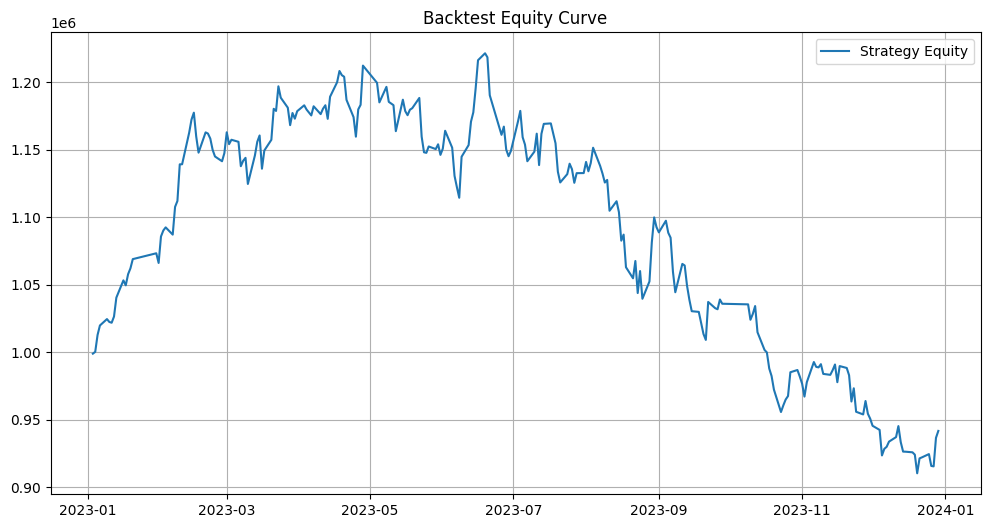

In [9]:
from qsys.backtest import BacktestEngine, Account

print("Starting Backtest...")

# Initialize Account
account = Account(init_cash=1_000_000)

# Run Engine
engine = BacktestEngine(
    account=account,
    daily_predictions=pred_test_df,
    start_date=test_period[0],
    end_date=test_period[1],
    top_k=30,
    n_drop=0  # Hold stocks until they drop out of Top 30
)

engine.run()

# Metrics
metrics = account.get_metrics()
print("\n=== Backtest Performance ===")
print(f"Total Return: {metrics['total_return']:.2%}")
print(f"Annualized Return: {metrics.get('annualized_return', 'N/A')}")
print(f"Max Drawdown: {metrics['max_drawdown']:.2%}")
print(f"Sharpe Ratio: {metrics.get('sharpe_ratio', 'N/A')}")

# Plot Equity Curve
history = pd.DataFrame(account.history)
history['date'] = pd.to_datetime(history['date'])
history.set_index('date', inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(history['total_assets'], label='Strategy Equity')
plt.title("Backtest Equity Curve")
plt.grid(True)
plt.legend()
plt.show()

## 6. Real-Time Trading (Live)

This section generates the **Trading Plan** for the *next trading day* and sends a notification.

### Workflow:
1.  **Update Data**: (Done in Step 2, ensure you run this after market close).
2.  **Predict**: Use the trained model to score all stocks for the latest available date.
3.  **Generate Plan**: Select Top 30 stocks to hold.
4.  **Notify**: Send the target portfolio to Enterprise WeChat.

In [10]:
from qsys.trader.notifier import Notifier

def generate_trading_plan(pred_df, top_k=30):
    if pred_df is None or pred_df.empty:
        return None
    if isinstance(pred_df.index, pd.MultiIndex):
        date_level = "datetime" if "datetime" in pred_df.index.names else pred_df.index.names[0]
        target_date = pred_df.index.get_level_values(date_level).max()
        df_target = pred_df.xs(target_date, level=date_level)
    else:
        target_date = pred_df.index.max()
        df_target = pred_df.loc[target_date]
    print(f"Generating plan based on data from: {target_date}")
    
    if df_target.empty:
        print("No data found for target date.")
        return None
        
    scores = df_target["score"] if "score" in df_target.columns else pd.Series(df_target.squeeze(), index=df_target.index)
    top_stocks = scores.sort_values(ascending=False).head(top_k)
    
    return top_stocks

# Generate Plan
plan = generate_trading_plan(pred_test_df, top_k=10)

if plan is not None:
    print("\n=== Trading Plan (Top 10) ===")
    print(plan)
    
    # Notify (Requires Webhook URL)
    # msg = f"SysQ Trading Plan for {test_period[1]}:\n" + plan.to_string()
    # notifier = Notifier(webhook_url="")
    # notifier.send_text(msg)
    print("\n[Notification] Webhook sending skipped (configure URL to enable).")

Generating plan based on data from: 2023-12-29 00:00:00

=== Trading Plan (Top 10) ===
instrument
605117.SH    0.122327
601901.SH    0.111994
688506.SH    0.074282
601318.SH    0.069518
601127.SH    0.056095
000157.SZ    0.048563
600886.SH    0.043907
000895.SZ    0.043387
002625.SZ    0.040890
002050.SZ    0.035470
Name: score, dtype: float64

[Notification] Webhook sending skipped (configure URL to enable).


## 7. Daily Automation Script

To automate this daily, you would use `scripts/update_data_csi300.py` and a similar prediction script triggered by `crontab` at 18:00 every trading day.

```bash
# Example Crontab
0 18 * * 1-5 /usr/bin/python3 /path/to/SysQ/scripts/update_data_csi300.py && /usr/bin/python3 /path/to/SysQ/scripts/run_daily_strategy.py
```